In [1]:
%%writefile worker.py
import numpy as np
import astropy.constants as const
import astropy.units as u
from astropy.cosmology import FlatLambdaCDM
from lenstronomy.LensModel.lens_model import LensModel
import warnings

warnings.filterwarnings("ignore")

cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
all_bands = [
    # 'g', 'r', 'i', 'z', 'y',
    'F062', 'F106', 'F129', 'F158', 'F184'
]


def extract_lens_properties(args):
    lens_id, lens = args
    
    deflector = lens.deflector
    source = lens.source(index=0)
    z_D = lens.deflector_redshift
    z_S = lens.source_redshift_list[0]
    theta_E = lens.einstein_radius[0]
    num_images = lens.image_number[0]

    xs, ys = lens.source(0).extended_source_position
    radial_dist_S = np.sqrt(xs**2 + ys**2)
    size_S = source.angular_size 

    mags = {}
    snrs = {}
    contrasts = {}
    
    fov_arcsec = np.max([theta_E * 4, 1])
    
    for b in all_bands:
        # Map to the correct observatory for SNR
        obs = 'LSST' if b in ['g', 'r', 'i', 'z', 'y'] else 'Roman'

        mags[f'mag_S_{b}'] = source.extended_source_magnitude(b)
        mags[f'mag_S_{b}_lensed'] = lens.extended_source_magnitude(band=b, lensed=True)[0]
        mags[f'mag_D_{b}'] = deflector.magnitude(b)
        
        # Calculate SNR
        snrs[f'snr_{b}'] = lens.snr(
            band=b,
            fov_arcsec=fov_arcsec,
            observatory=obs, 
            snr_per_pixel_threshold=1,
            exposure_time=642,  # seconds for Roman HLWAS Medium
        )
        
        # Calculate Contrast Ratio
        cr_raw = lens.contrast_ratio(band=b, source_index=0)
        cr_padded = np.array(list(cr_raw) + [np.nan] * (4 - len(cr_raw)))
        contrasts[f'contrast_ratio_{b}'] = cr_padded

    es_magnification = lens.extended_source_magnification[0]

    sigma_v_D = deflector.velocity_dispersion()
    stellar_mass_D = deflector.stellar_mass
    e1_mass_D, e2_mass_D = deflector.mass_ellipticity
    e_mass_D = np.sqrt(e1_mass_D**2 + e2_mass_D**2)
    gamma_pl = deflector.halo_properties.get('gamma_pl', 2.0)
    size_D = deflector.angular_size_light

    lenstronomy_kwargs = lens.lenstronomy_kwargs()
    lens_model_lenstronomy = LensModel(lens_model_list=lenstronomy_kwargs[0]["lens_model_list"])
    lenstronomy_kwargs_lens = lenstronomy_kwargs[1]["kwargs_lens"]
    
    deflector_center = deflector.deflector_center
    grid = np.linspace(-size_D, size_D, 500)
    grid_x, grid_y = np.meshgrid(grid + deflector_center[0], grid + deflector_center[1])
    
    kappa_map = lens_model_lenstronomy.kappa(grid_x, grid_y, kwargs=lenstronomy_kwargs_lens)
    mask = np.sqrt((grid_x - deflector_center[0])**2 + (grid_y - deflector_center[1])**2) < size_D / 2
    kappa_within_half_light_radii = np.nanmean(kappa_map[mask])

    D_s = cosmo.angular_diameter_distance(z_S)
    D_d = cosmo.angular_diameter_distance(z_D)
    D_ds = cosmo.angular_diameter_distance_z1z2(z_D, z_S)
    
    sigma_crit = ((const.c**2 / (4 * np.pi * const.G)) * (D_s / (D_d * D_ds))).to(u.Msun / u.pc**2).value
    surface_density = sigma_crit * kappa_within_half_light_radii

    surface_brightness_map = deflector.surface_brightness(grid_x, grid_y, band="g")
    mask_sb = np.sqrt((grid_x - deflector_center[0])**2 + (grid_y - deflector_center[1])**2) < size_D
    mean_surface_brightness = np.nanmean(surface_brightness_map[mask_sb])

    R_e_kpc_val = (cosmo.kpc_proper_per_arcmin(z_D) * ((size_D * u.arcsec).to(u.arcmin))).to(u.kpc).value

    return {
        "lens_id": lens_id, 
        "z_D": z_D, "z_S": z_S, "theta_E": theta_E, "num_images": num_images,
        "radial_dist_S": radial_dist_S, "size_S": size_S,
        **mags,
        **snrs,
        "es_magnification": es_magnification,
        "R_e_arcsec": size_D, "surf_bri_mag/arcsec2": mean_surface_brightness,
        "sigma_v_D": sigma_v_D, "stellar_mass_D": stellar_mass_D,
        "e1_mass_D": e1_mass_D, "e2_mass_D": e2_mass_D, "e_mass_D": e_mass_D,
        "gamma_pl": gamma_pl, 
        "R_e_kpc": R_e_kpc_val, "Sigma_half_Msun/pc2": surface_density,
        **contrasts
    }

Overwriting worker.py


In [2]:
import os
import copy
import numpy as np
import pandas as pd
import multiprocessing
import speclite
import speclite.filters
from tqdm import tqdm
from astropy.table import Table
from astropy.cosmology import FlatLambdaCDM
from astropy.units import Quantity

import slsim.Pipelines as pipelines
import slsim.Sources as sources
import slsim.Deflectors as deflectors
from slsim.Lenses.lens_pop import LensPop
from slsim.Pipelines import roman_speclite
from warnings import filterwarnings

filterwarnings("ignore", category=UserWarning, append=True)
filterwarnings("ignore", category=RuntimeWarning, append=True)

# Import the worker function
from worker import extract_lens_properties

# --- 1. Setup skypy_config & Roman Filters ---
skypy_config = "lsst-like_triple_SF.yml"

roman_speclite.configure_roman_filters()
roman_filters = roman_speclite.filter_names()
speclite.filters.load_filters(*roman_filters)

# --- 2. Configuration ---
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
sky_area = Quantity(value=10, unit="deg2")

# --- 3. Generate Catalogs In-Memory ---
galaxy_simulation_pipeline = pipelines.SkyPyPipeline(
    skypy_config=skypy_config, sky_area=sky_area, filters=None, cosmo=cosmo
)

red_galaxy_catalog = galaxy_simulation_pipeline.red_galaxies
blue_galaxy_catalog = galaxy_simulation_pipeline.blue_galaxies

kwargs_deflector_cut = {"band": "g", "band_max": 28, "z_min": 0.01, "z_max": 3}
kwargs_source_cut = {"band": "g", "band_max": 28, "z_min": 0.1, "z_max": 6.0}

lens_galaxies = deflectors.EllipticalLensGalaxies(
    galaxy_list=red_galaxy_catalog,
    kwargs_cut=kwargs_deflector_cut,
    kwargs_mass2light=None,
    cosmo=cosmo,
    sky_area=sky_area,
    gamma_pl={"mean": 2.078, "std_dev": 0.16},
)

source_galaxies = sources.Galaxies(
    galaxy_list=blue_galaxy_catalog,
    kwargs_cut=kwargs_source_cut,
    cosmo=cosmo,
    sky_area=sky_area,
    catalog_type="skypy",
    extended_source_type="single_sersic",
)

gg_lens_pop = LensPop(
    deflector_population=lens_galaxies,
    source_population=source_galaxies,
    cosmo=cosmo,
    sky_area=sky_area,
)

In [ ]:
# --- 4. Extract & Compile ---
scale_factor = 20 
all_results = []
num_processes = multiprocessing.cpu_count() - 3
multiprocessing.set_start_method("spawn", force=True)

for i in tqdm(range(scale_factor), desc="Drawing and Processing Lenses"):
    loaded_lenses = gg_lens_pop.draw_population(kwargs_lens_cuts={}, speed_factor=1)
    
    lens_ids = [f"lens_{i}_{j}" for j in range(len(loaded_lenses))]
    lens_args = list(zip(lens_ids, loaded_lenses))
    
    with multiprocessing.Pool(processes=num_processes) as pool:
        results_list = list(tqdm(
            pool.imap(extract_lens_properties, lens_args),
            total=len(loaded_lenses),
            desc="Calculating lens properties",
            leave=False
        ))
        
    all_results.extend([res for res in results_list if res is not None])

# Master Table
if all_results:
    final_catalog = Table.from_pandas(pd.DataFrame(all_results))
    print(f"\nSuccessfully generated {len(final_catalog)} lenses.")
else:
    final_catalog = None
    print("\nNo results were generated.")

# save the final catalog to a CSV file
# final_catalog.write(f"data/roman_gg_lens_catalog_{scale_factor*sky_area.value}_deg2_no_cuts.fits", format="fits", overwrite=True)

In [ ]:
if not final_catalog:
    final_catalog = Table.read(f"data/roman_gg_lens_catalog_{200.0}_deg2_no_cuts.fits", format="fits")

In [7]:
# --- 5. Cutting Logic ---
def satisfies_Collett_2015_cuts_table(lens_catalog_table, seeing=0.5, snr_threshold={'i': 20}, 
                                      redshift_limit_source=None, contrast_ratio_threshold_i_band=None, 
                                      return_boolean_array=False):
    """
    Checks whether lenses in a given lens catalog table satisfy the Collett 2015 cuts.
    """
    conditions = np.ones(len(lens_catalog_table), dtype=bool)

    # Criteria 1: Multiple imaging
    conditions &= lens_catalog_table['radial_dist_S'] < lens_catalog_table['theta_E']
    
    # Criteria 2: Image Resolution
    conditions &= lens_catalog_table['theta_E'] > np.sqrt(lens_catalog_table['size_S']**2 + (seeing/2)**2)
    
    # Criteria 3: Tangential Arc Resolution
    conditions &= lens_catalog_table['es_magnification'] * lens_catalog_table['size_S'] > seeing
    
    # Criteria 4: Magnification
    conditions &= lens_catalog_table['es_magnification'] > 3

    # Criteria 5: SNR > 20
    if snr_threshold is not None:
        for band, threshold in snr_threshold.items():
            if f'snr_{band}' in lens_catalog_table.colnames:
                snr_band = lens_catalog_table[f'snr_{band}'].copy()
                snr_band[snr_band == None] = 0  # Treat None SNR values as 0 for the purpose of this cut
                conditions &= snr_band > threshold
            
    # Criteria 6: Contrast Ratio (not in original Collett 2015 cuts, but often used in lens selection)
    # at least two images with contrast ratio > threshold in the i-band
    if contrast_ratio_threshold_i_band is not None and 'contrast_ratio_i' in lens_catalog_table.colnames:
        conditions_6 = np.ones(len(lens_catalog_table), dtype=bool)
        contrast_ratio_i = lens_catalog_table['contrast_ratio_i'] # this is in mags I_source_light/I_lens_light [mag/arcsec^2]
        for i in range(len(lens_catalog_table)):
            cr_i_lens = 10**(-contrast_ratio_i[i] / 2.5) # convert to flux ratio 
            cr_i_lens = cr_i_lens[~np.isnan(cr_i_lens)]  # remove nan values (for images that don't exist)
            if np.sum(cr_i_lens > contrast_ratio_threshold_i_band) < 2:
                conditions_6[i] = False
        conditions &= conditions_6

    # Criteria 7: Redshift cuts for Source if needed
    if redshift_limit_source is not None:
        conditions &= lens_catalog_table['z_S'] < redshift_limit_source
        
    if return_boolean_array:
        return conditions
    return lens_catalog_table[conditions]

In [8]:
filtered_catalog = satisfies_Collett_2015_cuts_table(
    final_catalog, 
    seeing=0.2, 
    snr_threshold={'F106': 20}, 
    redshift_limit_source=None, 
    contrast_ratio_threshold_i_band=2, 
    return_boolean_array=False
)
filtered_catalog

lens_id,z_D,z_S,theta_E,num_images,radial_dist_S,size_S,mag_S_F062,mag_S_F062_lensed,mag_D_F062,mag_S_F106,mag_S_F106_lensed,mag_D_F106,mag_S_F129,mag_S_F129_lensed,mag_D_F129,mag_S_F158,mag_S_F158_lensed,mag_D_F158,mag_S_F184,mag_S_F184_lensed,mag_D_F184,snr_F062,snr_F106,snr_F129,snr_F158,snr_F184,es_magnification,R_e_arcsec,surf_bri_mag/arcsec2,sigma_v_D,stellar_mass_D,e1_mass_D,e2_mass_D,e_mass_D,gamma_pl,R_e_kpc,Sigma_half_Msun/pc2,contrast_ratio_F062,contrast_ratio_F106,contrast_ratio_F129,contrast_ratio_F158,contrast_ratio_F184
str12,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,object,object,object,object,object
lens_0_1,0.3548015299390005,2.6349118573768036,1.335447355786595,2,0.6106335394175775,0.059709143130272854,25.475631616178656,23.834975762913032,18.716739561234448,25.027914729684124,23.3872588764185,17.49225989767981,24.68971684661494,23.049060993349315,17.141449974625395,24.106519784571073,22.46586393130545,16.903147109276986,23.862773370864385,22.22211751759876,16.79929863907588,39.704424785018105,44.892712979396435,49.824641732963244,73.99053183886981,67.12378759391423,4.531712413024927,0.8517411431736394,22.217356516841253,245.9679096066229,468798601859.96735,-0.08102851243190104,-0.0038758379982623964,0.08112115597743609,1.9050323713769108,4.2446892023070655,5921.795429398592,[-2.13263844 0.42475568 nan nan],[-1.35587566 1.20151845 nan nan],[-1.34326362 1.21413049 nan nan],[-1.68815782 0.8692363 nan nan],[-1.82805576 0.72933835 nan nan]
lens_0_5,1.1490912046569706,3.8916694509943106,0.40423963695344106,2,0.13131911547154648,0.0400975092200647,25.88677738103788,23.613694459256493,24.66059173640411,25.53245308646474,23.259370164683354,22.3219980052917,25.393628458724805,23.120545536943418,21.840247417362054,25.07620959989223,22.803126678110843,21.494183681627714,24.65032786838981,22.37724494660842,21.271399229514433,53.35584197714858,57.05468966690026,54.584492867641046,76.72427895323558,75.53894369920087,8.1139657228771,0.1885983585244183,24.255873337433226,169.0743548848626,141773299780.0552,0.04103233740283299,0.064123123216558,0.07612770615082137,2.1830834777032444,1.553502577803282,11076.951694580139,[-6.06019049 -4.86573177 nan nan],[-4.07592105 -2.88146233 nan nan],[-3.73299509 -2.53853637 nan nan],[-3.70435021 -2.5098915 nan nan],[-3.90744749 -2.71298878 nan nan]
lens_0_9,0.27804223577067166,1.5661053179931974,0.3153992052732886,2,0.1440106692710947,0.06779046784896556,24.93249446323206,23.311284843786375,21.237162330789968,23.807286648093132,22.186077028647446,20.122085471003228,23.259925833902486,21.6387162144568,19.786445294752657,22.888106270699325,21.26689665125364,19.594204054678865,22.65389141470525,21.032681795259563,19.479657206325545,56.95555943161092,97.96305408800713,119.17295550484401,147.70093298628905,121.5571403620559,4.4512690751241495,0.08264468353236888,19.547162468145654,120.66388329646803,22357969519.745266,0.034329950377556984,-0.020321080102985375,0.03989350560526704,2.193350217718464,0.3490050955034084,28506.663744304904,[-2.06948265 -0.23617452 nan nan],[-2.0796136 -0.24630547 nan nan],[-2.29133424 -0.45802611 nan nan],[-2.47091256 -0.63760443 nan nan],[-2.59058057 -0.75727244 nan nan]
lens_0_24,0.2946747204318797,3.232536131009301,0.41862207860815,2,0.19522758723481312,0.06058540754030016,25.521722170483123,24.059218836409165,20.52947712049955,25.24642482094565,23.78392148687169,19.43221340551466,25.010337544188566,23.54783421011461,19.099840122255074,24.555792280477554,23.093288946403597,18.910354743199,24.084171915639303,22.621668581565345,18.806511476061033,35.875996164610484,34.306331649418986,36.59168654721144,46.50180741046936,49.95194940422133,3.845929630499187,0.26056279793320636,21.237271367732326,135.2645602030279,501661

In [11]:
# Roman Medium HLWAS sky area is 2415 deg^2, so we can scale our results accordingly to estimate the number of lenses that would be found in the actual survey.
print(f"\nEstimated number of lenses in Roman Medium HLWAS (2415 deg^2): {len(filtered_catalog) * (2415 / (scale_factor*sky_area.value)):.0f}")


Estimated number of lenses in Roman Medium HLWAS (2415 deg^2): 78053


In [ ]:
# filtered_catalog.write(f"data/roman_gg_lens_catalog_{scale_factor*sky_area.value}_deg2_with_cuts.fits", format="fits", overwrite=True)

### Corner Plot of the Galaxy-Galaxy Lenses

Saved corner plot to proposal_figures_v2/roman_lens_distributions.pdf


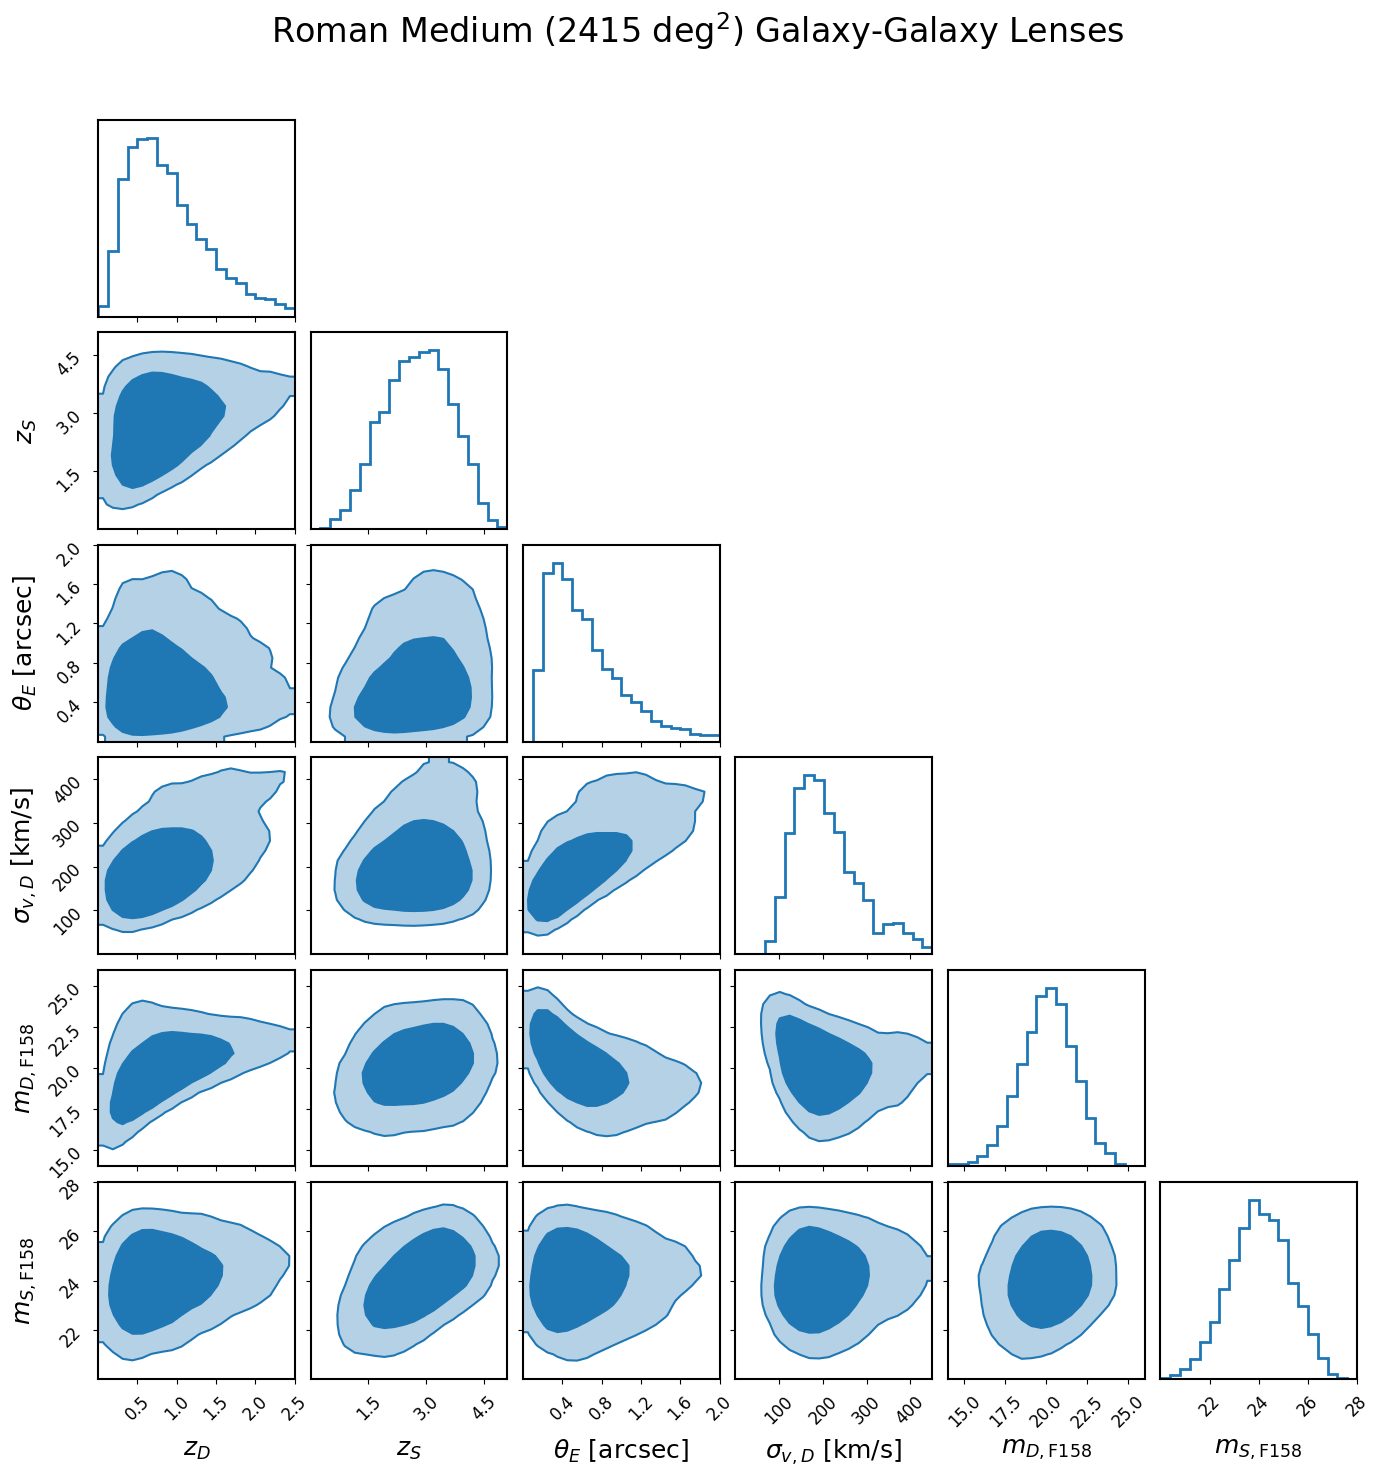

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import corner

def plot_roman_catalog_corner(catalog, save_path=None, custom_ranges=None, figsize=(14, 14)):
    """
    Generates a corner plot for the specified properties of the Roman galaxy-galaxy lenses,
    showing both 1D marginal distributions, 2D covariances, and median/error titles.
    Includes range control and layout adjustments to prevent title overlapping.
    """
    # 1. Define the exact keys you want to plot
    keys_to_plot = ['z_D', 'z_S', 'theta_E', 'sigma_v_D', 'mag_D_F158', 'mag_S_F158']
    
    # 2. Map them to their proper LaTeX representations
    latex_labels = {
        'z_D': r'$z_D$',
        'z_S': r'$z_S$',
        'theta_E': r'$\theta_E$ [arcsec]',
        'sigma_v_D': r'$\sigma_{v, D}$ [km/s]',
        'mag_D_F158': r'$m_{D, \rm F158}$',
        'mag_S_F158': r'$m_{S, \rm F158}$'
    }
    
    # Check that all keys exist in the catalog
    missing_keys = [k for k in keys_to_plot if k not in catalog.colnames]
    if missing_keys:
        raise ValueError(f"Missing columns in the provided catalog: {missing_keys}")

    # 3. Stack data into a 2D array of shape (N_samples, N_parameters)
    data_2d = np.vstack([catalog[k] for k in keys_to_plot]).T
    
    # Mask out any rows that have NaNs or Infs
    valid_mask = ~np.isnan(data_2d).any(axis=1) & ~np.isinf(data_2d).any(axis=1)
    clean_data = data_2d[valid_mask]
    
    # Ordered labels list
    labels = [latex_labels[k] for k in keys_to_plot]
    
    # 4. Initialize figure explicitly to control overall dimensions
    fig = plt.figure(figsize=figsize)
    
    # 5. Generate the Corner Plot
    fig = corner.corner(
        clean_data,
        fig=fig,                          # Pass the larger custom figure
        range=custom_ranges,              # ADDED: Range control
        labels=labels,
        show_titles=False,                 
        title_kwargs={"fontsize": 14},    # REDUCED: Helps prevent title overlap
        # quantiles=[0.16, 0.5, 0.84],      
        title_fmt=".2f",                  
        color='tab:blue',        
        smooth=1.0,              
        plot_datapoints=False,   
        plot_density=True,       
        fill_contours=True,
        levels=(0.68, 0.95),     
        hist_kwargs={"density": True, "linewidth": 2, "histtype": "step"},
        label_kwargs={"fontsize": 18}     
    )
    
    # ADDED: Small buffer space between panels to let the titles breathe
    fig.subplots_adjust(wspace=0.08, hspace=0.08)
    
    # 6. Fine-tune aesthetics (tick sizes, frame thickness)
    for ax in fig.get_axes():
        ax.tick_params(axis='both', which='major', labelsize=12, pad=6)
        for spine in ax.spines.values(): 
            spine.set_linewidth(1.5)

    # Add an overall title
    fig.suptitle("Roman Medium (2415 deg$^2$) Galaxy-Galaxy Lenses", fontsize=24, y=1.05)
    
    if save_path:
        fig.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"Saved corner plot to {save_path}")
        
    plt.show()
    return fig

roman_plot_ranges = [
    (0.0, 2.5),       # z_D
    (0.0, 5.1),       # z_S
    (0.0, 2.0),       # theta_E
    (0, 450),       # sigma_v_D
    (14, 26),         # mag_D_F158
    (20, 28)          # mag_S_F158
]

plot_roman_catalog_corner(
    filtered_catalog, 
    custom_ranges=roman_plot_ranges, 
    save_path="proposal_figures_v2/roman_lens_distributions.pdf"
);